In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor
from xgboost import XGBClassifier

import shap

c:\kaim\insurance-risk-analytics\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../data/insurance_data.txt",
    sep="|",
    low_memory=False
)

In [3]:
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)

In [4]:
df["VehicleAge"] = (
    2025 - df["RegistrationYear"]
)

In [5]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [21]:
numeric_features = [

    "VehicleAge",

    "Cylinders",

    "cubiccapacity",

    "kilowatts",

    "NumberOfDoors",

    "CustomValueEstimate",

    "SumInsured"
]

In [7]:
df["VehicleAge"] = (
    2025 - df["RegistrationYear"]
)

In [8]:
categorical_features = [

    "Province",

    "VehicleType",

    "make",

    "bodytype",

    "Gender",

    "CoverType",

    "CoverCategory",

    "Product",

    "TermFrequency"
]

In [22]:
features = (
    numeric_features +
    categorical_features
)

In [24]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [25]:
severity_df = df[
    df["TotalClaims"] > 0
].copy()

In [26]:
X = severity_df[features]

y = severity_df["TotalClaims"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
linear_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
linear_preds = linear_model.predict(
    X_test
)

In [30]:
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_preds
    )
)

linear_r2 = r2_score(
    y_test,
    linear_preds
)

print("RMSE:", linear_rmse)
print("R²:", linear_r2)

RMSE: 38986.80714929214
R²: 0.054890077961510575


The relatively weak performance of the linear regression model suggests that claim severity relationships are highly nonlinear and complex. This motivates the use of more advanced ensemble methods such as Random Forest and XGBoost.

In [31]:
rf_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
rf_preds = rf_model.predict(
    X_test
)

In [33]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_preds
    )
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("RMSE:", rf_rmse)
print("R²:", rf_r2)

RMSE: 36588.07503804389
R²: 0.16761143556518432


In [34]:
xgb_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBRegressor(

                n_estimators=100,

                learning_rate=0.1,

                max_depth=6,

                random_state=42,

                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
xgb_preds = xgb_model.predict(
    X_test
)

In [36]:
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_preds
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

RMSE: 38831.51145862375
R²: 0.06240437278170374


In [37]:
results = pd.DataFrame([

    {
        "Model": "Linear Regression",
        "RMSE": linear_rmse,
        "R²": linear_r2
    },

    {
        "Model": "Random Forest",
        "RMSE": rf_rmse,
        "R²": rf_r2
    },

    {
        "Model": "XGBoost",
        "RMSE": xgb_rmse,
        "R²": xgb_r2
    }

])

results

,Model,RMSE,R²
0,Linear Regression,38986.807149,0.054890
1,Random Forest,36588.075038,0.167611
2,XGBoost,38831.511459,0.062404


## Regression Model Comparison

Three regression algorithms were evaluated for claim severity prediction:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

The Random Forest model achieved the best overall performance, producing the lowest RMSE and highest R² score among the evaluated models.

This suggests that insurance claim severity relationships are highly nonlinear and involve complex feature interactions that are better captured by ensemble tree-based methods than by linear regression models.

In [38]:
X = df[features]

y = df["HasClaim"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
clf_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(

                n_estimators=100,

                random_state=42,

                n_jobs=-1,

                class_weight="balanced"
            )
        )
    ]
)

clf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
preds = clf_model.predict(
    X_test
)

In [42]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        preds
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        preds
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        preds
    )
)

Accuracy: 0.8925257474252575
Precision: 0.011979676502120916
Recall: 0.460573476702509
F1: 0.023351960383444642


## Classification Model Evaluation

A Random Forest classifier was trained to predict whether a policy would generate a claim.

### Results

- Accuracy: 89.25%
- Precision: 1.20%
- Recall: 46.06%
- F1 Score: 2.34%

### Interpretation

Although the classifier achieved relatively high accuracy, the dataset is highly imbalanced because claims are rare events. As a result, accuracy alone is not a reliable indicator of model quality.

The model achieved moderate recall, successfully identifying approximately 46% of actual claims. However, precision remained very low, indicating that many predicted claims were false positives.

This suggests that while the model can detect a meaningful portion of risky policies, additional tuning, resampling, or feature engineering would likely be required before deployment in a production pricing environment.

In [43]:
X_processed = preprocessor.fit_transform(X_train)

In [44]:
X_processed = X_processed.toarray()

In [45]:
rf = rf_model.named_steps["model"]

In [46]:
explainer = shap.TreeExplainer(rf)

In [47]:
sample_data = X_processed[:1000]

shap_values = explainer.shap_values(
    sample_data
)

In [49]:
feature_names = preprocessor.get_feature_names_out()

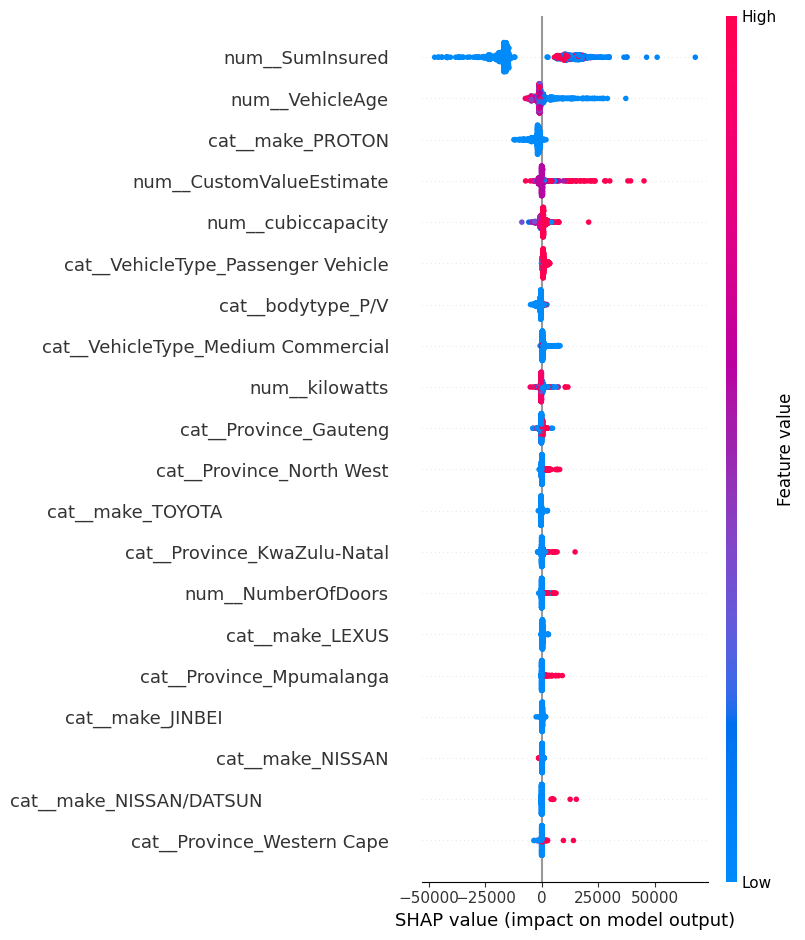

In [50]:
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names
)

## SHAP Feature Importance Analysis

SHAP analysis was performed on the best-performing Random Forest severity model to identify the most influential drivers of predicted claim severity.

### Key Findings

The most important predictive features included:

- SumInsured
- VehicleAge
- CustomValueEstimate
- cubiccapacity
- VehicleType
- Province
- Vehicle make

### Business Interpretation

The analysis indicates that higher insured amounts and higher vehicle values substantially increase predicted claim severity. Vehicle age also emerged as a major risk factor, suggesting that older vehicles may contribute to larger or more frequent repair costs.

Geographic variables such as province demonstrated measurable influence on predictions, reinforcing earlier hypothesis-testing findings that regional risk differences exist within the portfolio.

Vehicle type and manufacturer also contributed meaningfully to severity predictions, supporting the use of vehicle-based segmentation in pricing and underwriting strategies.

Overall, the SHAP analysis demonstrates that the model captures realistic insurance risk relationships and provides interpretable evidence for risk-based premium optimization.

# Risk-Based Pricing Framework

The predictive modeling framework supports a dynamic risk-based pricing strategy.

The proposed pricing approach combines:

1. Claim Probability Model
   - Estimates the probability that a policyholder will generate a claim.

2. Claim Severity Model
   - Estimates the expected financial impact of a claim.

The pricing framework can be expressed as:

Premium = (Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin

This approach enables premiums to better reflect underlying policy risk, improving both pricing fairness and portfolio profitability.

The Random Forest severity model demonstrated the strongest predictive performance among the evaluated regression models, while classification modeling highlighted the challenges associated with highly imbalanced insurance claim datasets.

# Final Conclusions

This project developed an end-to-end insurance risk analytics and predictive pricing framework.

Key accomplishments include:

- Exploratory data analysis of insurance portfolio risk factors
- Statistical hypothesis testing for geographic and demographic risk differences
- Data versioning and reproducibility using DVC
- Predictive modeling for claim severity and claim probability
- Model comparison across Linear Regression, Random Forest, and XGBoost
- SHAP-based explainability analysis for business interpretation

The Random Forest regression model achieved the best overall claim severity performance, demonstrating the importance of nonlinear feature interactions in insurance pricing.

The analysis further showed that insured value, vehicle age, geographic location, and vehicle characteristics are major drivers of predicted insurance risk.

Overall, the project demonstrates how statistical analysis and machine learning can support data-driven underwriting, portfolio segmentation, and dynamic premium optimization in the insurance industry.